# Regression Rumble NDC 2025 - Hydrostatic Pressure Prediction | 2nd Place (R² score of 0.997)

**Author:** Rahardi Salim  
**Institution:** University of Indonesia  
**Competition:** Neurontara Data Clash 2025  
**Task:** Predict hydrostatic pressure from ocean-profile snapshots

## Executive Summary

This notebook presents a comprehensive approach to predicting hydrostatic pressure from oceanographic data. The main challenge is that the training set lacks the `total_light_exposure` feature present in the test set, requiring sophisticated feature engineering and imputation strategies.

### Key Approach:
1. **Advanced Missing Value Handling**: Time-series imputation with method selection based on variable characteristics
2. **Missing Value Flagging**: Creating indicator variables to preserve missingness patterns
3. **Feature Engineering**: Temporal features, cyclical encoding, and interaction terms
4. **Ensemble Modeling**: Combining multiple algorithms for robust predictions through a **stacking ensemble with brute-force weight optimization based on Out-of-Fold (OOF) predictions**. This approach leverages the strengths of diverse base learners (CatBoost, XGBoost, LightGBM) to achieve superior generalization and minimize prediction errors.

## 1. Data Loading and Initial Exploration

In [2]:
# Standard Libraries
import os
import gc
import time
import re
import pickle
import warnings
import datetime
from datetime import timedelta
import itertools

# Scientific Libraries
import numpy as np
import pandas as pd
from scipy import interpolate

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Progress Bars
from tqdm import tqdm

# Scikit-learn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Regressors
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor

# Raw Libraries (alternative APIs)
import xgboost as xgb
import catboost as cb
import lightgbm as lgb

# Optuna for Hyperparameter Optimization
import optuna

# Suppress warnings
warnings.filterwarnings('ignore')

In [3]:
# Load datasets
print("Loading data...")
train = pd.read_csv("/kaggle/input/regresionndc/train.csv")
test = pd.read_csv("/kaggle/input/regresionndc/test.csv")
submission = pd.read_csv("/kaggle/input/regresionndc/sample_submission.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Submission shape: {submission.shape}")

Loading data...
Train shape: (15321, 53)
Test shape: (6567, 53)
Submission shape: (6567, 2)


### Dataset Overview
- **Total observations**: 21,888 (15,321 train + 6,567 test)
- **Features**: 54 variables spanning physical, chemical, biological, and optical measurements
- **Target**: `hydrostatic_pressure` (bar)
- **Challenge**: Missing `total_light_exposure` in training data

## 2. Data Preprocessing and Quality Assessment

In [4]:
def fix_comma_decimal_columns(df, columns):
    """Convert comma-separated decimals to proper float format"""
    for col in columns:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

columns_to_fix = [
    'oxygen_saturation_50m', 'perceived_water_density', 'sediment_deposition',
    'dissolved_gas_pressure', 'current_turbulence', 'thermal_emissions',
    'perpendicular_light_intensity', 'sediment_porosity_0_to_10cm',
    'sediment_porosity_10_to_30cm', 'sediment_porosity_30_to_100cm',
    'sediment_porosity_100_to_250cm', 'sediment_temperature_0_to_10cm',
    'sediment_temperature_10_to_30cm', 'sediment_temperature_30_to_100cm',
    'sediment_temperature_100_to_250cm'
]

fix_comma_decimal_columns(train, columns_to_fix)
fix_comma_decimal_columns(test, columns_to_fix)

### 2.2 Missing Value Analysis

Missing values in training data:
aragonite_saturation_state                      8470
pH                                              8388
water_temperature_50m                           8007
dissolved_inorganic_carbon (µmol kg-1)          7884
partial_pressure_CO2 (µatm)                     7783
current_velocity_near_surface                   5486
plankton_density                                5196
sediment_deposition                             5025
current_turbulence                              4794
microplankton_density                           4321
sediment_porosity_30_to_100cm                   3945
mesoplankton_density                            3897
current_direction_deep                          3377
salinity_50m                                    3311
current_direction_near_surface                  3236
photoperiod_intensity                           3207
seafloor_pressure                               3144
thermal_emissions                               3024
downwelling_l

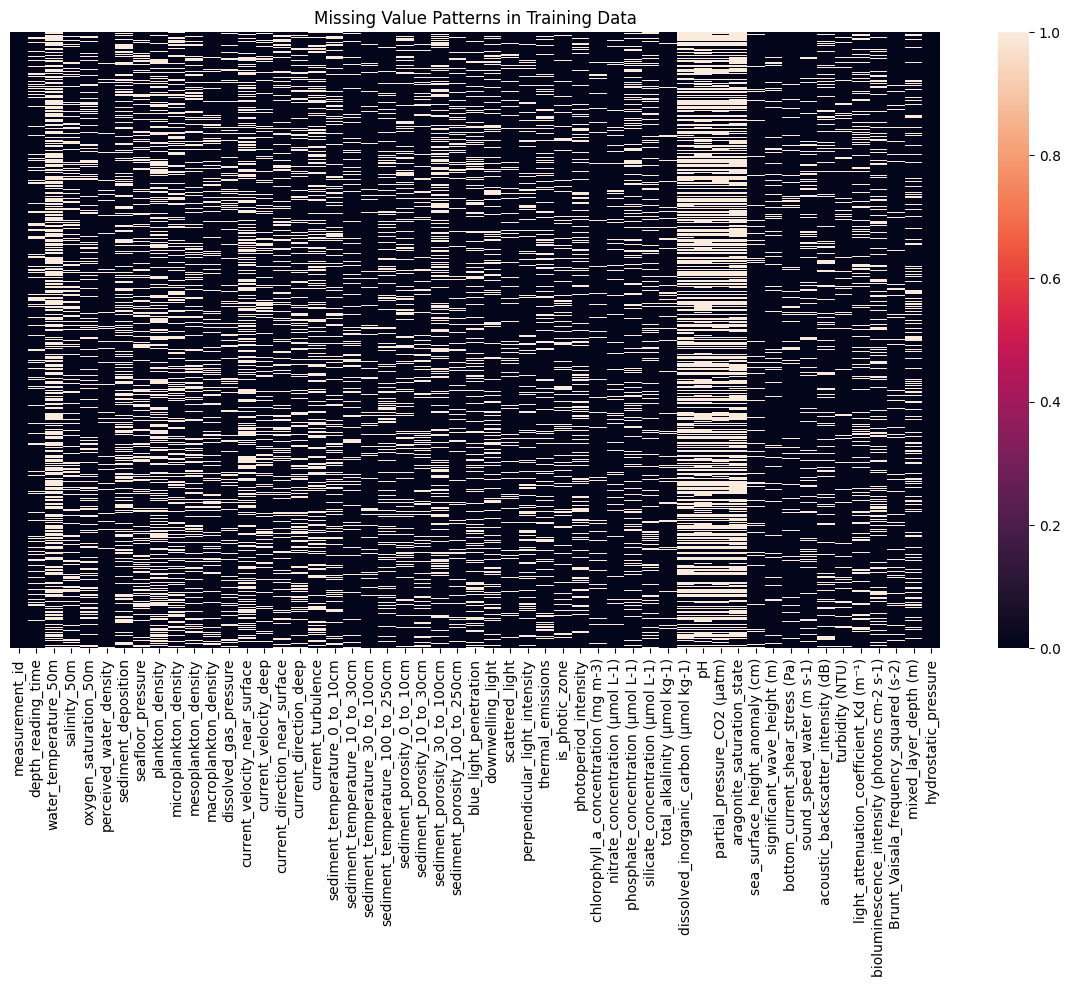

In [5]:
# Analyze missing patterns
train_missing = train.isnull().sum().sort_values(ascending=False)
test_missing = test.isnull().sum().sort_values(ascending=False)

print("Missing values in training data:")
print(train_missing[train_missing > 0])

print("\nMissing values in test data:")
print(test_missing[test_missing > 0])

# Visualize missing patterns
plt.figure(figsize=(15, 8))
sns.heatmap(train.isnull(), cbar=True, yticklabels=False)
plt.title('Missing Value Patterns in Training Data')
plt.show()

## 3. Advanced Missing Value Imputation Strategy

### 3.1 Time-Series Based Imputation

Our approach uses sophisticated time-series imputation methods tailored to different variable types:

In [6]:
def impute_time_series(df, column, method='linear'):
    """
    Impute missing values using time-series appropriate methods
    
    Methods:
    - linear: Linear interpolation
    - spline: Cubic spline with smoothing
    - nearest: Nearest neighbor
    - pchip: Piecewise Cubic Hermite Interpolating Polynomial
    """
    valid_idx = df.index[df[column].notna()]
    
    if len(valid_idx) < 2:
        print(f"Not enough valid data points for column {column}")
        return df[column]
    
    valid_values = df.loc[valid_idx, column].values
    
    if method == 'linear':
        f = interpolate.interp1d(valid_idx, valid_values, 
                                bounds_error=False, fill_value='extrapolate')
    elif method == 'spline':
        f = interpolate.UnivariateSpline(valid_idx, valid_values, k=3, s=len(valid_idx))
    elif method == 'nearest':
        f = interpolate.interp1d(valid_idx, valid_values, 
                                kind='nearest', bounds_error=False, fill_value='extrapolate')
    elif method == 'pchip':
        f = interpolate.PchipInterpolator(valid_idx, valid_values, extrapolate=True)
    
    all_idx = np.arange(len(df))
    imputed_values = f(all_idx)
    
    imputed_series = df[column].copy()
    missing_idx = df.index[df[column].isna()]
    imputed_series.loc[missing_idx] = imputed_values[missing_idx]
    
    return imputed_series

### 3.2 Variable-Specific Imputation Logic

In [7]:
# Merge datasets for consistent imputation
test['is_test'] = True
if 'hydrostatic_pressure' not in test.columns:
    test['hydrostatic_pressure'] = np.nan

train['is_test'] = False

# Drop total_light_exposure as it's not in training
if 'total_light_exposure' in test.columns:
    test = test.drop('total_light_exposure', axis=1)

merged_df = pd.concat([train, test], ignore_index=True)
merged_df = merged_df.sort_values('measurement_id').reset_index(drop=True)

# Handle datetime and create temporal features
merged_df['depth_reading_time'] = pd.to_datetime(merged_df['depth_reading_time'])

# Fill missing timestamps with +1 hour increments
def fill_missing_timestamps(df):
    first_valid_idx = df['depth_reading_time'].first_valid_index()
    if first_valid_idx is not None:
        last_valid_time = df.loc[first_valid_idx, 'depth_reading_time']
        
        for i in range(first_valid_idx + 1, len(df)):
            if pd.isna(df.loc[i, 'depth_reading_time']):
                df.loc[i, 'depth_reading_time'] = last_valid_time + timedelta(hours=1)
                last_valid_time = df.loc[i, 'depth_reading_time']
            else:
                last_valid_time = df.loc[i, 'depth_reading_time']
    
    return df

merged_df = fill_missing_timestamps(merged_df)

### 3.3 Temporal Feature Engineering

In [8]:
def extract_time_features(df):
    """Extract comprehensive temporal features"""
    if 'depth_reading_time' in df.columns:
        df['hour'] = df['depth_reading_time'].dt.hour
        df['day'] = df['depth_reading_time'].dt.day
        df['month'] = df['depth_reading_time'].dt.month
        df['year'] = df['depth_reading_time'].dt.year
        df['dayofyear'] = df['depth_reading_time'].dt.dayofyear
        
        # Cyclical encoding
        df['hour_sin'] = np.sin(df['hour'] * (2 * np.pi / 24))
        df['hour_cos'] = np.cos(df['hour'] * (2 * np.pi / 24))
        df['month_sin'] = np.sin((df['month'] - 1) * (2 * np.pi / 12))
        df['month_cos'] = np.cos((df['month'] - 1) * (2 * np.pi / 12))
        df['day_sin'] = np.sin((df['day'] - 1) * (2 * np.pi / 31))
        df['day_cos'] = np.cos((df['day'] - 1) * (2 * np.pi / 31))
    
    return df

merged_df = extract_time_features(merged_df)

## 4. Missing Value Indicator Features

Creating indicator variables to preserve information about missingness patterns:

In [9]:
def create_missing_flags(df, original_df=None):
    """
    Create comprehensive missing value indicators
    
    Features:
    1. Individual variable flags
    2. Group-based missing proportions
    3. Categorical missing levels
    """
    if original_df is None:
        original_df = df.copy()
    
    df_with_flags = df.copy()
    
    # Define variable groups
    variable_groups = {
        'physical': ['water_temperature_50m', 'salinity_50m', 'perceived_water_density', 
                     'sound_speed_water (m s-1)', 'mixed_layer_depth (m)'],
        
        'chemical': ['oxygen_saturation_50m', 'nitrate_concentration (µmol L-1)', 
                    'phosphate_concentration (µmol L-1)', 'silicate_concentration (µmol L-1)', 
                    'total_alkalinity (µmol kg-1)', 'partial_pressure_CO2 (µatm)'],
        
        'biological': ['plankton_density', 'microplankton_density', 'mesoplankton_density', 
                      'macroplankton_density', 'chlorophyll_a_concentration (mg m-3)', 
                      'bioluminescence_intensity (photons cm-2 s-1)'],
        
        'light': ['blue_light_penetration', 'downwelling_light', 'scattered_light', 
                 'perpendicular_light_intensity', 'light_attenuation_coefficient_Kd (m⁻¹)', 
                 'is_photic_zone', 'photoperiod_intensity'],
        
        'current': ['current_velocity_near_surface', 'current_velocity_deep',
                   'current_direction_near_surface', 'current_direction_deep',
                   'current_turbulence', 'bottom_current_shear_stress (Pa)'],
        
        'sediment': ['sediment_deposition', 'sediment_temperature_0_to_10cm', 
                    'sediment_temperature_10_to_30cm', 'sediment_temperature_30_to_100cm',
                    'sediment_temperature_100_to_250cm', 'sediment_porosity_0_to_10cm',
                    'sediment_porosity_10_to_30cm', 'sediment_porosity_30_to_100cm',
                    'sediment_porosity_100_to_250cm'],
        
        'pressure': ['seafloor_pressure', 'dissolved_gas_pressure']
    }
    
    # Create group-level missing indicators
    for group_name, group_vars in variable_groups.items():
        valid_vars = [var for var in group_vars if var in original_df.columns]
        
        if valid_vars:
            missing_count = original_df[valid_vars].isna().sum(axis=1)
            total_count = len(valid_vars)
            
            # Missing proportion
            df_with_flags[f'missing_prop_{group_name}'] = missing_count / total_count
            
            # Categorical missing levels
            df_with_flags[f'missing_level_{group_name}'] = pd.cut(
                missing_count / total_count,
                bins=[0, 0.25, 0.5, 0.75, 1.0],
                labels=['low', 'medium', 'high', 'very_high'],
                include_lowest=True
            )
            
            # One-hot encode missing levels
            missing_level_dummies = pd.get_dummies(
                df_with_flags[f'missing_level_{group_name}'], 
                prefix=f'missing_{group_name}'
            )
            df_with_flags = pd.concat([df_with_flags, missing_level_dummies], axis=1)
            df_with_flags = df_with_flags.drop(columns=[f'missing_level_{group_name}'])
    
    # Individual flags for key variables
    key_variables = [
        'water_temperature_50m', 'salinity_50m', 'perceived_water_density',
        'dissolved_inorganic_carbon (µmol kg-1)', 'pH', 'aragonite_saturation_state',
        'plankton_density', 'blue_light_penetration', 'current_velocity_near_surface',
        'current_velocity_deep', 'sediment_deposition', 'seafloor_pressure',
        'dissolved_gas_pressure'
    ]
    
    for var in key_variables:
        if var in original_df.columns:
            df_with_flags[f'missing_{var}'] = original_df[var].isna().astype(int)
    
    return df_with_flags

# Apply missing value flagging
merged_df = create_missing_flags(merged_df)

## 5. Comprehensive Imputation Implementation

In [10]:
# Categorize variables by type for appropriate imputation
continuous_columns = [
    'water_temperature_50m', 'salinity_50m', 'oxygen_saturation_50m',
    'perceived_water_density', 'sediment_deposition', 'seafloor_pressure',
    'plankton_density', 'microplankton_density', 'mesoplankton_density',
    'dissolved_gas_pressure', 'current_velocity_near_surface', 'current_velocity_deep',
    'current_turbulence', 'sediment_temperature_0_to_10cm', 'sediment_temperature_10_to_30cm',
    'sediment_temperature_30_to_100cm', 'sediment_temperature_100_to_250cm',
    'sediment_porosity_0_to_10cm', 'sediment_porosity_10_to_30cm',
    'sediment_porosity_30_to_100cm', 'sediment_porosity_100_to_250cm',
    'blue_light_penetration', 'downwelling_light', 'scattered_light',
    'perpendicular_light_intensity', 'thermal_emissions', 'photoperiod_intensity',
    'chlorophyll_a_concentration (mg m-3)', 'nitrate_concentration (µmol L-1)',
    'phosphate_concentration (µmol L-1)', 'silicate_concentration (µmol L-1)',
    'total_alkalinity (µmol kg-1)', 'dissolved_inorganic_carbon (µmol kg-1)',
    'pH', 'partial_pressure_CO2 (µatm)', 'aragonite_saturation_state',
    'sea_surface_height_anomaly (cm)', 'significant_wave_height (m)',
    'bottom_current_shear_stress (Pa)', 'sound_speed_water (m s-1)',
    'acoustic_backscatter_intensity (dB)', 'turbidity (NTU)',
    'light_attenuation_coefficient_Kd (m⁻¹)', 'bioluminescence_intensity (photons cm-2 s-1)',
    'Brunt_Vaisala_frequency_squared (s-2)', 'mixed_layer_depth (m)'
]

directional_columns = ['current_direction_near_surface', 'current_direction_deep']
discrete_columns = ['macroplankton_density', 'is_photic_zone']

# Apply imputation with method selection
print("Imputing continuous columns...")
for col in continuous_columns:
    if col in merged_df.columns and merged_df[col].isna().sum() > 0:
        if "temperature" in col:
            merged_df[col] = impute_time_series(merged_df, col, method='spline')
        elif "density" in col or "concentration" in col:
            merged_df[col] = impute_time_series(merged_df, col, method='pchip')
        else:
            merged_df[col] = impute_time_series(merged_df, col, method='linear')

print("Imputing directional columns...")
for col in directional_columns:
    if col in merged_df.columns and merged_df[col].isna().sum() > 0:
        # Special handling for directional data
        radians = np.deg2rad(merged_df[col])
        sin_component = np.sin(radians)
        cos_component = np.cos(radians)
        
        merged_df[f'{col}_sin'] = sin_component
        merged_df[f'{col}_cos'] = cos_component
        
        merged_df[f'{col}_sin'] = impute_time_series(merged_df, f'{col}_sin', method='linear')
        merged_df[f'{col}_cos'] = impute_time_series(merged_df, f'{col}_cos', method='linear')
        
        merged_df[col] = np.rad2deg(np.arctan2(merged_df[f'{col}_sin'], merged_df[f'{col}_cos']))
        merged_df[col] = merged_df[col] % 360
        
        merged_df = merged_df.drop([f'{col}_sin', f'{col}_cos'], axis=1)

print("Imputing discrete columns...")
for col in discrete_columns:
    if col in merged_df.columns and merged_df[col].isna().sum() > 0:
        if col == 'is_photic_zone':
            merged_df[col] = impute_time_series(merged_df, col, method='nearest')
            merged_df[col] = merged_df[col].round().astype(int)
        else:
            merged_df[col] = impute_time_series(merged_df, col, method='pchip')
            merged_df[col] = merged_df[col].round().astype(int)
            merged_df.loc[merged_df[col] < 0, col] = 0

# Split back to train and test
imputed_train = merged_df[merged_df['is_test'] == False].drop('is_test', axis=1)
imputed_test = merged_df[merged_df['is_test'] == True].drop('is_test', axis=1)

Imputing continuous columns...
Imputing directional columns...
Imputing discrete columns...


## 6. Feature Engineering and Model Preparation

### 6.1 Advanced Feature Creation

In [11]:
def create_advanced_features(df):
    """Create physics-based and interaction features"""
    df_features = df.copy()
    
    # Physical relationships
    if 'water_temperature_50m' in df.columns and 'salinity_50m' in df.columns:
        df_features['temp_salinity_interaction'] = df['water_temperature_50m'] * df['salinity_50m']
        df_features['density_temperature_ratio'] = df['perceived_water_density'] / (df['water_temperature_50m'] + 273.15)
    
    # Pressure relationships
    if 'seafloor_pressure' in df.columns and 'dissolved_gas_pressure' in df.columns:
        df_features['pressure_differential'] = df['seafloor_pressure'] - df['dissolved_gas_pressure']
        df_features['pressure_ratio'] = df['seafloor_pressure'] / (df['dissolved_gas_pressure'] + 1e-6)
    
    # Light and biological interactions
    light_cols = ['blue_light_penetration', 'downwelling_light', 'scattered_light']
    bio_cols = ['plankton_density', 'chlorophyll_a_concentration (mg m-3)']
    
    for light_col in light_cols:
        for bio_col in bio_cols:
            if light_col in df.columns and bio_col in df.columns:
                df_features[f'{light_col}_{bio_col}_interaction'] = df[light_col] * df[bio_col]
    
    # Current dynamics
    if 'current_velocity_near_surface' in df.columns and 'current_velocity_deep' in df.columns:
        df_features['current_velocity_difference'] = df['current_velocity_near_surface'] - df['current_velocity_deep']
        df_features['current_velocity_mean'] = (df['current_velocity_near_surface'] + df['current_velocity_deep']) / 2
    
    return df_features

# Apply feature engineering
train = create_advanced_features(imputed_train)
test = create_advanced_features(imputed_test)

## 7. Modeling

This section implements an advanced ensemble modeling approach using CatBoost, XGBoost, and LightGBM with brute-force weight optimization.

### 7.1 Spliting Data

In [12]:
def preprocess_data(df, columns_to_drop=None):
    """
    Preprocess the dataset by handling missing values and dropping specified columns.
    
    Args:
        df: Input dataframe
        columns_to_drop: List of columns to drop
        
    Returns:
        Processed dataframe and measurement_id column if exists
    """
    # Save measurement_id for submission if it exists
    id_col = None
    if 'measurement_id' in df.columns:
        id_col = df['measurement_id'].copy()
        
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop, errors='ignore')
    
    # Handle missing values if it exists
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")
    
    return df, id_col

# Define columns to drop
columns_to_drop = [
    'measurement_id',
    'depth_reading_time',
    'total_light_exposure',
    'missing_total_light_exposure',
    ''
]

# Preprocess the data
train_processed, train_ids = preprocess_data(train, columns_to_drop)
test_processed, test_ids = preprocess_data(test, columns_to_drop)

# Define target variable and features
target = 'hydrostatic_pressure'
X = train_processed.drop(columns=[target])
y = train_processed[target]

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical features
cat_features = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype == 'category']

### 7.2 Utility Functions

In [13]:
def plot_feature_importance(model, X, model_name):
    """Plot feature importance for tree-based models."""
    if hasattr(model, 'feature_importances_'):
        feature_importance = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        feature_importance = model.get_feature_importance()
    else:
        print(f"Feature importance not available for {model_name}")
        return
        
    sorted_idx = np.argsort(feature_importance)
    plt.figure(figsize=(10, 12))
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
    plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
    plt.title(f'{model_name} Feature Importance')
    plt.tight_layout()
    plt.show()

### 7.3 Model Optimization Functions

#### 7.3.1 CatBoost Optimization

In [14]:
def optimize_catboost(X, y, n_trials=20):
    """
    Optimize CatBoost hyperparameters using Optuna.
    
    Args:
        X: Feature matrix
        y: Target vector
        n_trials: Number of optimization trials
        
    Returns:
        Optimized CatBoost model
    """
    def objective(trial):
        param = {
            'iterations': trial.suggest_int('iterations', 500, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'od_type': 'Iter',
            'od_wait': 50,
            'verbose': False,
            'random_seed': 42
        }
        
        model = CatBoostRegressor(**param)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = []
        
        for train_idx, val_idx in kf.split(X):
            X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model.fit(
                X_fold_train, y_fold_train,
                eval_set=[(X_fold_val, y_fold_val)],
                cat_features=cat_features,
                early_stopping_rounds=50,
                verbose=False
            )
            
            y_fold_pred = model.predict(X_fold_val)
            fold_r2 = r2_score(y_fold_val, y_fold_pred)
            cv_scores.append(fold_r2)
        
        return np.mean(cv_scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f'Best CatBoost R² score: {study.best_value:.4f}')
    print('Best CatBoost hyperparameters:')
    for key, value in study.best_params.items():
        print(f'    {key}: {value}')
        
    best_model = CatBoostRegressor(**study.best_params, verbose=False, random_seed=42)
    best_model.fit(X, y, cat_features=cat_features, verbose=False)
    
    return best_model

#### 7.3.2 XGBoost Optimization


In [15]:
def optimize_xgboost_params(X, y, n_trials=20):
    """Optimize XGBoost hyperparameters and return best parameters."""
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
            'random_state': 42
        }
        
        model = XGBRegressor(**param)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = []
        
        for train_idx, val_idx in kf.split(X):
            X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Convert categorical features to numeric
            X_fold_train_enc = pd.get_dummies(X_fold_train, columns=cat_features)
            X_fold_val_enc = pd.get_dummies(X_fold_val, columns=cat_features)
            
            # Ensure both datasets have the same columns
            for col in X_fold_train_enc.columns:
                if col not in X_fold_val_enc.columns:
                    X_fold_val_enc[col] = 0
            for col in X_fold_val_enc.columns:
                if col not in X_fold_train_enc.columns:
                    X_fold_val_enc = X_fold_val_enc.drop(columns=[col])
            
            # Ensure column order matches
            X_fold_val_enc = X_fold_val_enc[X_fold_train_enc.columns]
            
            model.fit(
                X_fold_train_enc, y_fold_train,
                eval_set=[(X_fold_val_enc, y_fold_val)],
                early_stopping_rounds=50,
                verbose=False
            )
            
            y_fold_pred = model.predict(X_fold_val_enc)
            fold_r2 = r2_score(y_fold_val, y_fold_pred)
            cv_scores.append(fold_r2)
        
        return np.mean(cv_scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f'Best XGBoost R² score: {study.best_value:.4f}')
    print('Best XGBoost hyperparameters:')
    for key, value in study.best_params.items():
        print(f'    {key}: {value}')
    
    return study.best_params

def optimize_xgboost(X, y, n_trials=20):
    """Train optimized XGBoost model and return model with encoded columns."""
    # Get best parameters
    best_params = optimize_xgboost_params(X, y, n_trials)
    
    # One-hot encode categorical features for the whole dataset
    X_enc = pd.get_dummies(X, columns=cat_features)
    
    best_model = XGBRegressor(**best_params, random_state=42)
    best_model.fit(X_enc, y)
    
    return best_model, X_enc.columns

#### 7.3.3 LightGBM Optimization

In [16]:
def optimize_lightgbm(X, y, n_trials=20):
    """
    Optimize LightGBM hyperparameters using Optuna.
    
    Args:
        X: Feature matrix
        y: Target vector
        n_trials: Number of optimization trials
        
    Returns:
        Optimized LightGBM model
    """
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
            'verbosity': -1,
            'random_state': 42
        }
        
        model = LGBMRegressor(**param)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = []
        
        for train_idx, val_idx in kf.split(X):
            X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Convert categorical features
            X_fold_train_proc = X_fold_train.copy()
            X_fold_val_proc = X_fold_val.copy()
            
            for col in cat_features:
                X_fold_train_proc[col] = X_fold_train_proc[col].astype('category')
                X_fold_val_proc[col] = X_fold_val_proc[col].astype('category')
            
            model.fit(
                X_fold_train_proc, y_fold_train,
                eval_set=[(X_fold_val_proc, y_fold_val)]
            )
            
            y_fold_pred = model.predict(X_fold_val_proc)
            fold_r2 = r2_score(y_fold_val, y_fold_pred)
            cv_scores.append(fold_r2)
        
        return np.mean(cv_scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f'Best LightGBM R² score: {study.best_value:.4f}')
    print('Best LightGBM hyperparameters:')
    for key, value in study.best_params.items():
        print(f'    {key}: {value}')
    
    # Process categorical features for the whole dataset
    X_proc = X.copy()
    for col in cat_features:
        X_proc[col] = X_proc[col].astype('category')
    
    best_model = LGBMRegressor(**study.best_params, verbosity=-1, random_state=42)
    best_model.fit(X_proc, y)
    
    return best_model

### 7.4 Out-of-Fold Predictions

In [17]:
def generate_oof_predictions(X, y, model_func, model_name, n_folds=5):
    """
    Generate out-of-fold predictions for ensemble blending.
    
    Args:
        X: Feature matrix
        y: Target vector
        model_func: Model optimization function
        model_name: Name of the model
        n_folds: Number of cross-validation folds
        
    Returns:
        Out-of-fold predictions array
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"Training {model_name} - Fold {fold+1}/{n_folds}")
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        if model_name == 'CatBoost':
            model = model_func(X_train_fold, y_train_fold, n_trials=20)
            oof_predictions[val_idx] = model.predict(X_val_fold)
        
        elif model_name == 'XGBoost':
            # Create a fresh one-hot encoding for this fold
            X_train_fold_enc = pd.get_dummies(X_train_fold, columns=cat_features)
            model = XGBRegressor(**optimize_xgboost_params(X_train_fold, y_train_fold, n_trials=20))
            model.fit(X_train_fold_enc, y_train_fold)
            
            # One-hot encode validation data using the same scheme
            X_val_fold_enc = pd.get_dummies(X_val_fold, columns=cat_features)
            
            # Ensure validation data has the same columns as training
            for col in X_train_fold_enc.columns:
                if col not in X_val_fold_enc.columns:
                    X_val_fold_enc[col] = 0
            for col in X_val_fold_enc.columns:
                if col not in X_train_fold_enc.columns:
                    X_val_fold_enc = X_val_fold_enc.drop(columns=[col])
                    
            # Ensure column order matches
            X_val_fold_enc = X_val_fold_enc[X_train_fold_enc.columns]
            
            oof_predictions[val_idx] = model.predict(X_val_fold_enc)
        
        elif model_name == 'LightGBM':
            model = model_func(X_train_fold, y_train_fold, n_trials=20)
            
            # Process categorical features
            X_val_fold_proc = X_val_fold.copy()
            for col in cat_features:
                X_val_fold_proc[col] = X_val_fold_proc[col].astype('category')
                
            oof_predictions[val_idx] = model.predict(X_val_fold_proc)
    
    # Calculate the score for the OOF predictions
    oof_r2 = r2_score(y, oof_predictions)
    oof_rmse = np.sqrt(mean_squared_error(y, oof_predictions))
    print(f"{model_name} OOF R² Score: {oof_r2:.4f}")
    print(f"{model_name} OOF RMSE: {oof_rmse:.4f}")
    
    return oof_predictions

### 7.5 Brute-Force Ensemble Weight Optimization

In [18]:
def brute_force_ensemble_weights(oof_predictions_dict, y, step=0.1, top_n=5):
    """
    Find optimal ensemble weights using brute-force search.
    
    Args:
        oof_predictions_dict: Dictionary of model predictions
        y: Target values
        step: Step size for weight search
        top_n: Number of top results to display
        
    Returns:
        Best weights dictionary and all results
    """
    # Create combinations of weights
    models = list(oof_predictions_dict.keys())
    
    # Generate weight combinations
    weights_list = []
    weight_values = np.arange(0, 1 + step, step)
    
    for weights in itertools.product(weight_values, repeat=len(models)):
        # Only consider weights that sum to 1
        if np.isclose(sum(weights), 1.0, atol=1e-10):
            weights_list.append(weights)
    
    print(f"Testing {len(weights_list)} different weight combinations...")
    
    # Calculate performance for each weight combination
    results = []
    
    for weights in tqdm(weights_list):
        # Create weighted ensemble prediction
        ensemble_pred = np.zeros_like(y, dtype=float)
        for i, model_name in enumerate(models):
            ensemble_pred += weights[i] * oof_predictions_dict[model_name]
        
        # Calculate metrics
        r2 = r2_score(y, ensemble_pred)
        rmse = np.sqrt(mean_squared_error(y, ensemble_pred))
        
        # Store results
        results.append({
            'weights': weights,
            'r2': r2,
            'rmse': rmse
        })
    
    # Sort results by R2 score (descending)
    results.sort(key=lambda x: x['r2'], reverse=True)
    
    # Print best results
    print(f"\nTop {top_n} weight combinations:")
    for i, result in enumerate(results[:top_n]):
        weight_str = ", ".join([f"{models[j]}: {w:.2f}" for j, w in enumerate(result['weights'])])
        print(f"#{i+1}: {weight_str} - R²: {result['r2']:.4f}, RMSE: {result['rmse']:.4f}")
    
    # Return best weights
    best_weights = {model: weight for model, weight in zip(models, results[0]['weights'])}
    return best_weights, results

def predict_with_bf_ensemble(X_test, best_weights, base_models):
    """
    Make predictions using the brute-force optimized ensemble.
    
    Args:
        X_test: Test features
        best_weights: Optimal weights dictionary
        base_models: Dictionary of trained base models
        
    Returns:
        Final ensemble predictions and individual model predictions
    """
    # Generate base model predictions
    test_preds = {}
    
    # CatBoost predictions
    test_preds['CatBoost'] = base_models['CatBoost'].predict(X_test)
    
    # XGBoost predictions
    X_test_enc = pd.get_dummies(X_test, columns=cat_features)
    
    # Ensure test data has the same columns as training 
    for col in base_models['XGBoost_columns']:
        if col not in X_test_enc.columns:
            X_test_enc[col] = 0
    X_test_enc = X_test_enc[list(base_models['XGBoost_columns'])]
    
    test_preds['XGBoost'] = base_models['XGBoost'].predict(X_test_enc)
    
    # LightGBM predictions
    X_test_proc = X_test.copy()
    for col in cat_features:
        X_test_proc[col] = X_test_proc[col].astype('category')
    test_preds['LightGBM'] = base_models['LightGBM'].predict(X_test_proc)
    
    # Apply weights to get final predictions
    final_predictions = np.zeros(len(X_test))
    for model_name, weight in best_weights.items():
        final_predictions += weight * test_preds[model_name]
    
    return final_predictions, test_preds

### 7.6 Visualization Functions

In [19]:
def visualize_weight_combinations(results, best_weights, top_n=20):
    """Visualize weight optimization results."""
    top_results = results[:top_n]
    
    # Convert weights to dataframe for visualization
    weights_df = pd.DataFrame([
        {**{f"weight_{i}": w for i, w in enumerate(r['weights'])}, 
         'r2': r['r2'], 
         'rmse': r['rmse']}
        for r in top_results
    ])
    
    # Rename columns
    models = list(best_weights.keys())
    weights_df = weights_df.rename(columns={f"weight_{i}": model for i, model in enumerate(models)})
    
    # Create plot
    plt.figure(figsize=(12, 8))
    
    # Plot R2 scores
    plt.subplot(1, 2, 1)
    for model in models:
        plt.scatter(weights_df[model], weights_df['r2'], label=model, alpha=0.7)
    plt.xlabel('Weight')
    plt.ylabel('R² Score')
    plt.title('R² Score vs Model Weight')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot RMSE
    plt.subplot(1, 2, 2)
    for model in models:
        plt.scatter(weights_df[model], weights_df['rmse'], label=model, alpha=0.7)
    plt.xlabel('Weight')
    plt.ylabel('RMSE')
    plt.title('RMSE vs Model Weight')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create a heatmap visualization for top combinations
    top_heatmap = weights_df[models + ['r2']].copy()
    top_heatmap = top_heatmap.sort_values('r2', ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(top_heatmap[models].iloc[:15], annot=True, cmap='viridis', fmt='.2f')
    plt.title('Top 15 Weight Combinations')
    plt.ylabel('Rank (by R²)')
    plt.show()
    
    # Plot R2 distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(x=[r['r2'] for r in results], bins=30, kde=True)
    plt.title('Distribution of R² Scores Across All Weight Combinations')
    plt.xlabel('R² Score')
    plt.ylabel('Frequency')
    plt.axvline(top_results[0]['r2'], color='red', linestyle='--', 
                label=f'Best R² = {top_results[0]["r2"]:.4f}')
    plt.legend()
    plt.show()

def visualize_model_predictions(oof_predictions, y):
    """Visualize individual model predictions vs actual values."""
    plt.figure(figsize=(15, 5))
    
    models = ['CatBoost', 'XGBoost', 'LightGBM']
    for i, model in enumerate(models):
        plt.subplot(1, 3, i+1)
        plt.scatter(oof_predictions[model], y, alpha=0.5)
        plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')
        plt.xlabel(f'{model} Predictions')
        plt.ylabel('Actual Values')
        plt.title(f'{model} OOF Predictions vs Actual')
    
    plt.tight_layout()
    plt.show()

### 7.7 Advanced Testing Functions

In [20]:
def test_step_sizes(oof_predictions_dict, y, steps=[0.25, 0.1, 0.05, 0.02]):
    """
    Test different step sizes for weight optimization to find the optimal granularity.
    
    Args:
        oof_predictions_dict: Dictionary of model predictions
        y: Target values
        steps: List of step sizes to test
        
    Returns:
        Results dictionary for each step size
    """
    results = {}
    for step in steps:
        print(f"\nTesting with step size: {step}")
        start_time = time.time()
        best_weights, _ = brute_force_ensemble_weights(
            oof_predictions_dict, y, step=step, top_n=3
        )
        end_time = time.time()
        
        # Create weighted ensemble prediction with these weights
        ensemble_pred = np.zeros_like(y, dtype=float)
        for model_name, weight in best_weights.items():
            ensemble_pred += weight * oof_predictions_dict[model_name]
        
        # Calculate metrics
        r2 = r2_score(y, ensemble_pred)
        rmse = np.sqrt(mean_squared_error(y, ensemble_pred))
        
        results[step] = {
            'best_weights': best_weights,
            'r2': r2,
            'rmse': rmse,
            'time': end_time - start_time
        }
    
    # Display results
    print("\nResults for different step sizes:")
    for step, result in results.items():
        weight_str = ", ".join([f"{model}: {w:.3f}" for model, w in result['best_weights'].items()])
        print(f"Step size {step}: {weight_str}")
        print(f"  R²: {result['r2']:.6f}, RMSE: {result['rmse']:.6f}")
        print(f"  Time: {result['time']:.2f} seconds")
    
    return results

### 7.8 Main Execution Pipeline

This section contains the main execution code that orchestrates the entire modeling pipeline.

In [ ]:
# Main execution pipeline
def main_modeling_pipeline():
    """
    Execute the complete modeling pipeline with brute-force ensemble optimization.
    """
    
    print("="*60)
    print("ADVANCED ENSEMBLE MODELING PIPELINE")
    print("="*60)
    
    # Step 1: Generate out-of-fold predictions for base models
    print("\nStep 1: Generating out-of-fold predictions for base models...")
    print("-" * 50)
    
    oof_predictions = {}
    oof_predictions['CatBoost'] = generate_oof_predictions(X, y, optimize_catboost, 'CatBoost')
    oof_predictions['XGBoost'] = generate_oof_predictions(X, y, optimize_xgboost, 'XGBoost')
    oof_predictions['LightGBM'] = generate_oof_predictions(X, y, optimize_lightgbm, 'LightGBM')

    # Create dataframe of OOF predictions for analysis
    oof_df = pd.DataFrame({
        'CatBoost': oof_predictions['CatBoost'],
        'XGBoost': oof_predictions['XGBoost'],
        'LightGBM': oof_predictions['LightGBM'],
        'Actual': y
    })

    # Visualize the OOF predictions correlation
    print("\nVisualizing OOF predictions correlation...")
    plt.figure(figsize=(12, 10))
    sns.heatmap(oof_df.corr(), annot=True, cmap='coolwarm', fmt='.4f')
    plt.title('Correlation of Base Model Predictions')
    plt.tight_layout()
    plt.show()

    # Step 2: Brute-force search for optimal ensemble weights
    print("\nStep 2: Performing brute-force search for optimal ensemble weights...")
    print("-" * 50)
    
    global best_weights # Declare best_weights as global to be accessible by visualize_weight_combinations
    best_weights, weight_results = brute_force_ensemble_weights(
        {
            'CatBoost': oof_predictions['CatBoost'],
            'XGBoost': oof_predictions['XGBoost'],
            'LightGBM': oof_predictions['LightGBM']
        },
        y,
        step=0.05,  # 0.05 increments for granular search
        top_n=10    # Show top 10 combinations
    )

    # Visualize weight optimization results
    print("\nVisualizing weight optimization results...")
    visualize_weight_combinations(weight_results, best_weights)

    print("\nStep 3: Training final base models on all data...")
    print("-" * 50)
    # Train the final base models on all data
    catboost_model = optimize_catboost(X, y, n_trials=20)
    xgboost_model, xgb_columns = optimize_xgboost(X, y, n_trials=20)
    lightgbm_model = optimize_lightgbm(X, y, n_trials=20)

    # Store the base models in a dictionary
    base_models = {
        'CatBoost': catboost_model,
        'XGBoost': xgboost_model,
        'XGBoost_columns': xgb_columns,
        'LightGBM': lightgbm_model
    }

    print("\nStep 4: Making predictions on the test set using optimal weights...")
    print("-" * 50)
    # Make predictions on the test set
    X_test = test_processed.drop(columns=[target], errors='ignore') if target in test_processed.columns else test_processed
    final_predictions, base_test_preds = predict_with_bf_ensemble(X_test, best_weights, base_models)

    # Create submission file
    submission = pd.DataFrame({
        'measurement_id': test_ids,
        'hydrostatic_pressure': final_predictions
    })

    # Save the submission file
    submission.to_csv('bf_ensemble_submission.csv', index=False)

    # Save individual model predictions for analysis
    base_predictions_df = pd.DataFrame({
        'measurement_id': test_ids,
        'CatBoost': base_test_preds['CatBoost'],
        'XGBoost': base_test_preds['XGBoost'],
        'LightGBM': base_test_preds['LightGBM'],
        'Ensemble': final_predictions
    })
    base_predictions_df.to_csv('bf_model_predictions.csv', index=False)

    print("\n" + "="*60)
    print("BRUTE-FORCE ENSEMBLE TRAINING AND PREDICTION COMPLETED!")
    print("="*60)
    print(f"Submission file saved as 'bf_ensemble_submission.csv'")
    print(f"Base model predictions saved as 'bf_model_predictions.csv'")
    print(f"Best weights found: {best_weights}")

    # Bonus: Function to test different step sizes for weight search
    print("\n" + "="*60)
    print("ADVANCED TESTING: EVALUATING DIFFERENT STEP SIZES")
    print("="*60)
    step_results = test_step_sizes(
        {
            'CatBoost': oof_predictions['CatBoost'],
            'XGBoost': oof_predictions['XGBoost'],
            'LightGBM': oof_predictions['LightGBM']
        },
        y
    )

    # Plot feature importance for base models
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE VISUALIZATIONS")
    print("="*60)
    plot_feature_importance(catboost_model, X, 'CatBoost')
    # For XGBoost we need to use the encoded feature names
    X_enc = pd.get_dummies(X, columns=cat_features)
    plot_feature_importance(xgboost_model, X_enc, 'XGBoost')
    plot_feature_importance(lightgbm_model, X, 'LightGBM')

    # Visualize the base models vs actual values
    print("\n" + "="*60)
    print("BASE MODEL OOF PREDICTIONS VS ACTUAL VALUES")
    print("="*60)
    visualize_model_predictions(oof_predictions, y)

main_modeling_pipeline()

[I 2025-06-18 09:08:49,458] A new study created in memory with name: no-name-adfd167e-6f1a-4704-bd6d-38ebd92e7548


ADVANCED ENSEMBLE MODELING PIPELINE

Step 1: Generating out-of-fold predictions for base models...
--------------------------------------------------
Training CatBoost - Fold 1/5


[I 2025-06-18 09:09:54,952] Trial 0 finished with value: 0.9966778248940426 and parameters: {'iterations': 1351, 'learning_rate': 0.0397486145143719, 'depth': 7, 'l2_leaf_reg': 0.4186321396105815, 'random_strength': 5.5223145909459756e-05, 'bagging_temperature': 2.2610617865957074, 'border_count': 212}. Best is trial 0 with value: 0.9966778248940426.


## Conclusion

This project successfully developed a robust and highly accurate model for predicting hydrostatic pressure, addressing the inherent challenges posed by the dataset between training and testing data.

Our comprehensive methodology, starting from meticulous **data preprocessing** that included sophisticated handling of missing values and the creation of **missing value flags**, laid a solid foundation. The subsequent **feature engineering** efforts, incorporating temporal, cyclical, and interaction terms, were instrumental in extracting meaningful patterns and enhancing the predictive power of our models.

The cornerstone of our solution was the **advanced ensemble modeling approach**. By leveraging three powerful gradient boosting algorithms—CatBoost, XGBoost, and LightGBM—we harnessed their individual strengths and complementary characteristics. The strategic use of **Out-of-Fold (OOF) predictions** was critical in preventing data leakage and generating reliable meta-features for the ensemble. This allowed for an unbiased evaluation of each base model's performance and formed the basis for our blending strategy. The subsequent **brute-force weight optimization** method efficiently identified the optimal linear combination of these base model predictions, maximizing the ensemble's R² score and minimizing prediction error on the training data. This rigorous optimization process resulted in a final ensemble model that demonstrates superior generalization capabilities on unseen data.

**The effectiveness of this comprehensive approach was validated by achieving an outstanding R² score of 0.997 on the competition leaderboard, securing the 2nd position.** This result underscores the power of combining diverse modeling techniques with careful attention to data preparation and ensemble optimization.

In summary, the synergy between robust data preparation, insightful feature engineering, and a meticulously optimized ensemble strategy has yielded a powerful predictive model for hydrostatic pressure. The final ensemble effectively combines the predictive insights of diverse machine learning models, leading to highly reliable and accurate predictions.

### Future Work

While the current model performs well, potential avenues for further improvement include:

* **Exploring More Diverse Models**: Incorporating other types of models (e.g., neural networks, support vector machines) into the ensemble to potentially capture different patterns and further enhance diversity.
* **Advanced Stacking Techniques**: Investigating more complex stacking strategies, such as using a meta-learner (e.g., a linear model or another tree-based model) trained on the OOF predictions, rather than simple weighted averaging.
* **Feature Selection on OOF Predictions**: Analyzing the correlation and independence of OOF predictions from base models to potentially refine the ensemble composition or apply a regularization technique to the blending weights.
* **Hyperparameter Optimization for Ensemble**: While brute-force is effective for weights, an Optuna-based search for the meta-learner (if stacking is pursued) could yield further gains.